# 5G - XGBoost and lightGBM modeling 

# Step 1 — Target encoding & class reframing

Our objective is probabilistic classification: output P(QoS met | slice_type=k) for k ∈ {1, 2, 3}. This means We need to reframe the problem clearly before touching any model.
Approach: One-vs-Rest (OvR) multiclass with predict_proba. XGBoost and LightGBM both support multi:softprob / multiclass objectives natively, which outputs a probability vector of length 3 per row — exactly what you need.

In [1]:
import pandas as pd

train_df = pd.read_csv("train_dataset_prepared.csv")
test_df = pd.read_csv("test_dataset_prepared.csv")

In [2]:
# STEP 1 — Label check & encoding
# Your target column is "slice Type" with values 1, 2, 3
# Tree models handle integer labels natively BUT XGBoost requires 0-indexed labels

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(train_df["slice Type"])  # maps {1,2,3} -> {0,1,2}


# Keep a mapping for readability later
label_map = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label mapping:", label_map)  # {1:0, 2:1, 3:2}

# Feature matrix
feature_cols = [c for c in train_df.columns if c != "slice Type"]
X_train = train_df[feature_cols].copy()
X_test  = test_df[feature_cols].copy()

Label mapping: {np.int64(1): np.int64(0), np.int64(2): np.int64(1), np.int64(3): np.int64(2)}


# Step 2 — Feature engineering

Based on our EDA, we have: Time, Packet Loss Rate, Packet delay, LTE/5g Category (continuous), plus a set of binary features. For 5G QoS prediction, the following engineered features are meaningful:

In [3]:
# STEP 2 — Clean feature selection + engineering
import numpy as np

# Start from clean features only — no leaky identity columns
clean_cols = ["Time", "Packet Loss Rate", "Packet delay", "LTE/5g Category"]
X_train_clean = train_df[clean_cols].copy()
X_test_clean  = test_df[clean_cols].copy()

def engineer_features(df):
    df = df.copy()
    
    # Interaction: delay + loss together describe link quality
    df["delay_x_loss"] = df["Packet delay"] * df["Packet Loss Rate"]
    
    # Ratio: high delay but low loss = congestion, not error
    df["delay_per_loss"] = df["Packet delay"] / (df["Packet Loss Rate"] + 1e-6)
    
    # Network category weighted delay
    df["category_delay"] = df["LTE/5g Category"] * df["Packet delay"]
    
    # Log-transform skewed features
    df["log_packet_loss"] = np.log1p(df["Packet Loss Rate"])
    df["log_packet_delay"] = np.log1p(df["Packet delay"])
    
    return df

X_train = engineer_features(X_train_clean)
X_test  = engineer_features(X_test_clean)

print(f"Features after engineering: {X_train.shape[1]}")
print(f"Feature names: {X_train.columns.tolist()}")

Features after engineering: 9
Feature names: ['Time', 'Packet Loss Rate', 'Packet delay', 'LTE/5g Category', 'delay_x_loss', 'delay_per_loss', 'category_delay', 'log_packet_loss', 'log_packet_delay']


# Step 3 — Preprocessing pipeline

In [4]:
# STEP 3 — Preprocessing

from sklearn.model_selection import train_test_split

# Split into 3 parts: train / calibration / evaluation
# train: model learns on this
# cal:   calibration is fitted on this  
# eval:  never touched until final evaluation

X_tr, X_temp, y_tr, y_temp = train_test_split(
    X_train, y_train,
    test_size=0.30,
    random_state=42,
    stratify=y_train
)

X_cal, X_eval, y_cal, y_eval = train_test_split(
    X_temp, y_temp,
    test_size=0.50,        # 15% cal, 15% eval
    random_state=42,
    stratify=y_temp
)

print(f"Train:       {X_tr.shape[0]} samples")
print(f"Calibration: {X_cal.shape[0]} samples")
print(f"Evaluation:  {X_eval.shape[0]} samples")

Train:       6270 samples
Calibration: 1344 samples
Evaluation:  1344 samples


# Step 4a — XGBoost baseline + tuning

In [7]:
# STEP 4a — XGBoost baseline + Optuna tuning
import xgboost as xgb
from sklearn.metrics import roc_auc_score, log_loss
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

num_classes = 3

# --- 4a.1 Baseline XGBoost ---
xgb_base = xgb.XGBClassifier(
    objective="multi:softprob", num_class=num_classes,
    eval_metric="mlogloss", n_estimators=500,
    learning_rate=0.1, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    early_stopping_rounds=30, random_state=42, n_jobs=-1
)

# FIXED: X_tr_unscaled → X_tr, y_tr_bal → y_tr, X_val_unscaled → X_cal, y_val → y_cal
xgb_base.fit(X_tr, y_tr,
             eval_set=[(X_cal, y_cal)], verbose=False)

y_prob_xgb_base = xgb_base.predict_proba(X_cal)
print("XGBoost Baseline:")
print(f"  Log-loss: {log_loss(y_cal, y_prob_xgb_base):.4f}")
print(f"  AUC-ROC:  {roc_auc_score(y_cal, y_prob_xgb_base, multi_class='ovr', average='macro'):.4f}")


# --- 4a.2 Optuna tuning ---
def xgb_objective(trial):
    params = {
        "objective": "multi:softprob", "num_class": num_classes,
        "eval_metric": "mlogloss",
        "n_estimators":     trial.suggest_int("n_estimators", 200, 1000),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth":        trial.suggest_int("max_depth", 3, 9),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma":            trial.suggest_float("gamma", 0, 5),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-8, 1.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-8, 1.0, log=True),
        "random_state": 42, "n_jobs": -1, "early_stopping_rounds": 30,
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_tr, y_tr,
              eval_set=[(X_cal, y_cal)], verbose=False)
    return log_loss(y_cal, model.predict_proba(X_cal))

study_xgb = optuna.create_study(direction="minimize")
study_xgb.optimize(xgb_objective, n_trials=50)
print("Best XGBoost params:", study_xgb.best_params)

# --- Train final tuned model ---
xgb_tuned = xgb.XGBClassifier(
    **study_xgb.best_params,
    objective="multi:softprob", num_class=num_classes,
    random_state=42, n_jobs=-1
)
xgb_tuned.fit(X_tr, y_tr)

y_prob_xgb = xgb_tuned.predict_proba(X_cal)
print(f"\nXGBoost Tuned — "
      f"LogLoss: {log_loss(y_cal, y_prob_xgb):.4f}  "
      f"AUC: {roc_auc_score(y_cal, y_prob_xgb, multi_class='ovr', average='macro'):.4f}")

XGBoost Baseline:
  Log-loss: 0.0792
  AUC-ROC:  0.9940
Best XGBoost params: {'n_estimators': 334, 'learning_rate': 0.20886204899270255, 'max_depth': 5, 'min_child_weight': 1, 'subsample': 0.998916482697432, 'colsample_bytree': 0.8723847881976354, 'gamma': 0.44358994379653005, 'reg_alpha': 0.058527967973014, 'reg_lambda': 0.1968820150299713}

XGBoost Tuned — LogLoss: 0.0725  AUC: 0.9955


# Step 4b — LightGBM baseline + tuning

In [10]:
# STEP 4b — LightGBM baseline + Optuna tuning
import lightgbm as lgb

# --- 4b.1 Baseline LightGBM ---
lgb_base = lgb.LGBMClassifier(
    objective="multiclass", num_class=num_classes,
    metric="multi_logloss", n_estimators=500,
    learning_rate=0.1, num_leaves=31,
    subsample=0.8, colsample_bytree=0.8,
    n_jobs=-1, random_state=42, verbose=-1
)

lgb_base.fit(X_tr, y_tr,
             eval_set=[(X_cal, y_cal)],
             callbacks=[lgb.early_stopping(30, verbose=False),
                        lgb.log_evaluation(-1)])

y_prob_lgb_base = lgb_base.predict_proba(X_cal)
print("LightGBM Baseline:")
print(f"  Log-loss: {log_loss(y_cal, y_prob_lgb_base):.4f}")
print(f"  AUC-ROC:  {roc_auc_score(y_cal, y_prob_lgb_base, multi_class='ovr', average='macro'):.4f}")


# --- 4b.2 Optuna tuning ---
def lgb_objective(trial):
    params = {
        "objective": "multiclass", "num_class": num_classes,
        "metric": "multi_logloss",
        "n_estimators":      trial.suggest_int("n_estimators", 200, 1000),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 20, 150),
        "max_depth":         trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-8, 1.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-8, 1.0, log=True),
        "n_jobs": -1, "random_state": 42, "verbose": -1
    }
    model = lgb.LGBMClassifier(**params)
    model.fit(X_tr, y_tr,
              eval_set=[(X_cal, y_cal)],
              callbacks=[lgb.early_stopping(30, verbose=False),
                         lgb.log_evaluation(-1)])
    return log_loss(y_cal, model.predict_proba(X_cal))

study_lgb = optuna.create_study(direction="minimize",
                                 sampler=optuna.samplers.TPESampler(seed=42))
study_lgb.optimize(lgb_objective, n_trials=50)
print("Best LightGBM params:", study_lgb.best_params)


# --- Train final tuned model ---
lgb_tuned = lgb.LGBMClassifier(
    **study_lgb.best_params,
    objective="multiclass", num_class=num_classes,
    random_state=42, verbose=-1
)
lgb_tuned.fit(X_tr, y_tr)

y_prob_lgb = lgb_tuned.predict_proba(X_cal)
print(f"\nLightGBM Tuned — "
      f"LogLoss: {log_loss(y_cal, y_prob_lgb):.4f}  "
      f"AUC: {roc_auc_score(y_cal, y_prob_lgb, multi_class='ovr', average='macro'):.4f}")

LightGBM Baseline:
  Log-loss: 0.0897
  AUC-ROC:  0.9932
Best LightGBM params: {'n_estimators': 408, 'learning_rate': 0.06327303484675603, 'num_leaves': 66, 'max_depth': 3, 'min_child_samples': 16, 'subsample': 0.7218647458320882, 'colsample_bytree': 0.569066138409132, 'reg_alpha': 3.755862306612895e-07, 'reg_lambda': 3.3870387416741294e-08}

LightGBM Tuned — LogLoss: 0.0865  AUC: 0.9933


# Step 5 — Stratified k-fold cross-validation

This is the honest performance estimate. A single train/val split can be lucky or unlucky — k-fold averages across k different splits.

In [11]:
# STEP 5 — Stratified K-Fold CV
from sklearn.model_selection import StratifiedKFold
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def cross_validate_model(model, X, y, model_name="Model"):
    auc_scores, logloss_scores = [], []
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_fold_tr,  X_fold_val  = X.iloc[tr_idx],  X.iloc[val_idx]
        y_fold_tr,  y_fold_val  = y[tr_idx],        y[val_idx]
        model.fit(X_fold_tr, y_fold_tr)
        proba = model.predict_proba(X_fold_val)
        auc = roc_auc_score(y_fold_val, proba, multi_class='ovr', average='macro')
        ll  = log_loss(y_fold_val, proba)
        auc_scores.append(auc)
        logloss_scores.append(ll)
        print(f"  Fold {fold+1}: AUC={auc:.4f}  LogLoss={ll:.4f}")
    print(f"\n{model_name} CV Summary:")
    print(f"  AUC:     {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")
    print(f"  LogLoss: {np.mean(logloss_scores):.4f} ± {np.std(logloss_scores):.4f}")
    return np.mean(auc_scores), np.mean(logloss_scores)

print("=== XGBoost CV ===")
xgb_auc, xgb_ll = cross_validate_model(xgb_tuned, X_train, y_train, "XGBoost")

print("\n=== LightGBM CV ===")
lgb_auc, lgb_ll = cross_validate_model(lgb_tuned, X_train, y_train, "LightGBM")

best_model = xgb_tuned if xgb_ll < lgb_ll else lgb_tuned
best_name  = "XGBoost"  if xgb_ll < lgb_ll else "LightGBM"
print(f"\nBest model by log-loss: {best_name}")

=== XGBoost CV ===
  Fold 1: AUC=0.9939  LogLoss=0.0794
  Fold 2: AUC=0.9953  LogLoss=0.0756
  Fold 3: AUC=0.9960  LogLoss=0.0705
  Fold 4: AUC=0.9954  LogLoss=0.0689
  Fold 5: AUC=0.9937  LogLoss=0.0799

XGBoost CV Summary:
  AUC:     0.9949 ± 0.0009
  LogLoss: 0.0748 ± 0.0045

=== LightGBM CV ===
  Fold 1: AUC=0.9910  LogLoss=0.0990
  Fold 2: AUC=0.9922  LogLoss=0.0909
  Fold 3: AUC=0.9930  LogLoss=0.0846
  Fold 4: AUC=0.9936  LogLoss=0.0804
  Fold 5: AUC=0.9914  LogLoss=0.0954

LightGBM CV Summary:
  AUC:     0.9922 ± 0.0010
  LogLoss: 0.0901 ± 0.0068

Best model by log-loss: XGBoost


# Step 6 — Probability calibration

Raw XGBoost/LightGBM probabilities are often overconfident — they're close to 0 or 1 when the true probability should be something intermediate. Calibration corrects this so that when the model says 70%, the actual QoS failure rate is genuinely around 70%.

Before calibration — log-loss: 0.0725
After calibration  — log-loss: 0.0744


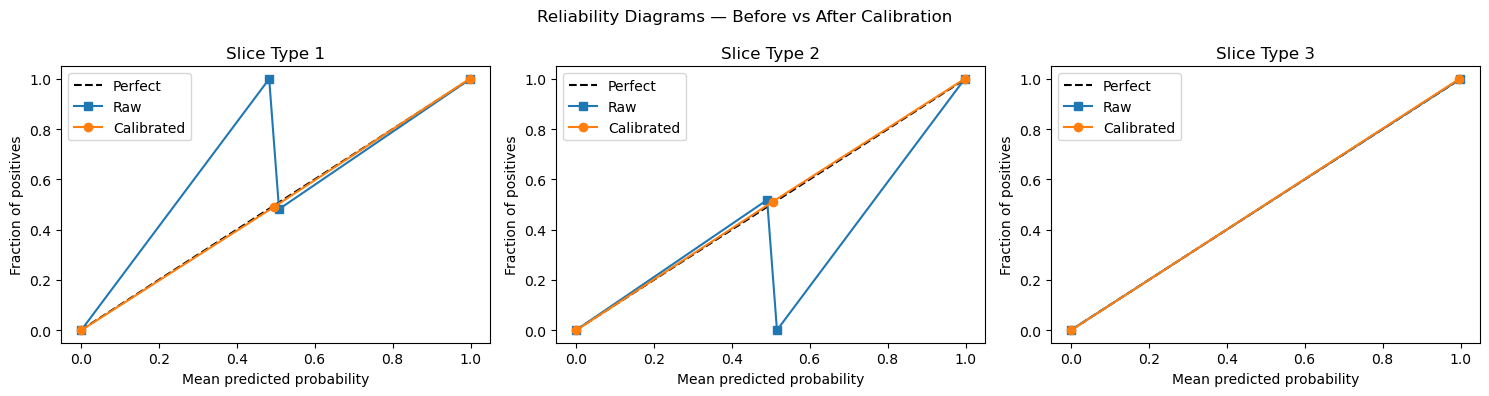

Slice 1 — Brier raw: 0.0259  calibrated: 0.0260
Slice 2 — Brier raw: 0.0259  calibrated: 0.0260
Slice 3 — Brier raw: 0.0000  calibrated: 0.0000


In [13]:
# STEP 6 — Probability Calibration
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

# Retrain best model on training set
best_model.fit(X_tr, y_tr)

# Calibrate on the dedicated calibration set
calibrated_model = CalibratedClassifierCV(
    FrozenEstimator(best_model),
    method="sigmoid"
)
calibrated_model.fit(X_cal, y_cal)

# Compare raw vs calibrated on cal set
y_prob_raw = best_model.predict_proba(X_cal)
y_prob_cal = calibrated_model.predict_proba(X_cal)

print(f"Before calibration — log-loss: {log_loss(y_cal, y_prob_raw):.4f}")
print(f"After calibration  — log-loss: {log_loss(y_cal, y_prob_cal):.4f}")

# Reliability diagrams
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for class_idx in range(3):
    y_binary = (y_cal == class_idx).astype(int)
    frac_pos_raw, mean_pred_raw = calibration_curve(
        y_binary, y_prob_raw[:, class_idx], n_bins=10)
    frac_pos_cal, mean_pred_cal = calibration_curve(
        y_binary, y_prob_cal[:, class_idx], n_bins=10)
    ax = axes[class_idx]
    ax.plot([0,1],[0,1],'k--', label="Perfect")
    ax.plot(mean_pred_raw, frac_pos_raw, 's-', label="Raw")
    ax.plot(mean_pred_cal, frac_pos_cal, 'o-', label="Calibrated")
    ax.set_title(f"Slice Type {class_idx+1}")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.legend()

plt.suptitle("Reliability Diagrams — Before vs After Calibration")
plt.tight_layout()
plt.show()

# Brier scores
for class_idx in range(3):
    y_bin  = (y_cal == class_idx).astype(int)
    bs_raw = brier_score_loss(y_bin, y_prob_raw[:, class_idx])
    bs_cal = brier_score_loss(y_bin, y_prob_cal[:, class_idx])
    print(f"Slice {class_idx+1} — Brier raw: {bs_raw:.4f}  calibrated: {bs_cal:.4f}")

# Step 7 — Final output + SHAP interpretation

   P_QoS_slice1  P_QoS_slice2  P_QoS_slice3  predicted_slice  risk_score
0      0.997490      0.001542      0.000968                1    0.002510
1      0.001312      0.001540      0.997147                3    0.002853
2      0.495707      0.503312      0.000982                2    0.496688
3      0.495707      0.503312      0.000982                2    0.496688
4      0.495707      0.503312      0.000982                2    0.496688
5      0.997483      0.001549      0.000968                1    0.002517
6      0.495707      0.503312      0.000982                2    0.496688
7      0.001319      0.997713      0.000968                2    0.002287
8      0.001312      0.001540      0.997147                3    0.002853
9      0.997490      0.001542      0.000968                1    0.002510

Risk score stats:
count    8960.0000
mean        0.0548
std         0.1517
min         0.0023
25%         0.0025
50%         0.0025
75%         0.0029
max         0.4967
Name: risk_score, dtype: f

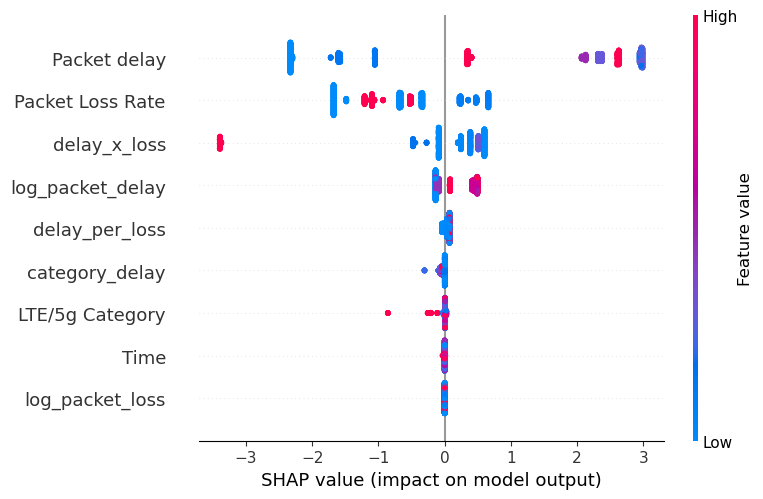


SHAP Summary — Slice Type 2


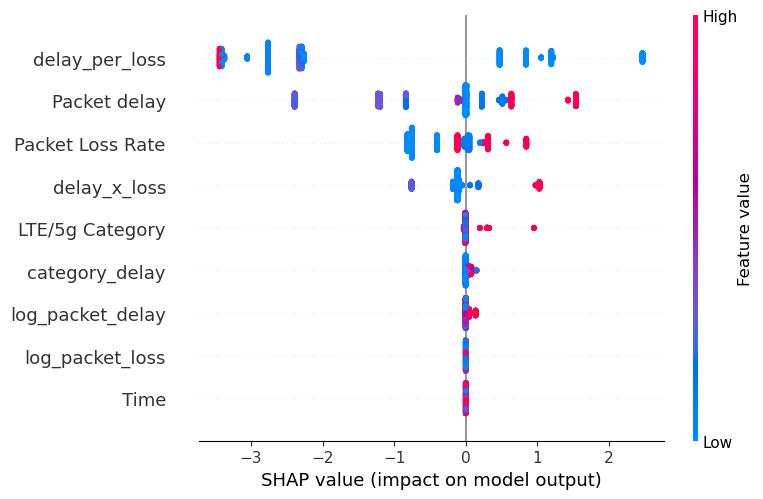


SHAP Summary — Slice Type 3


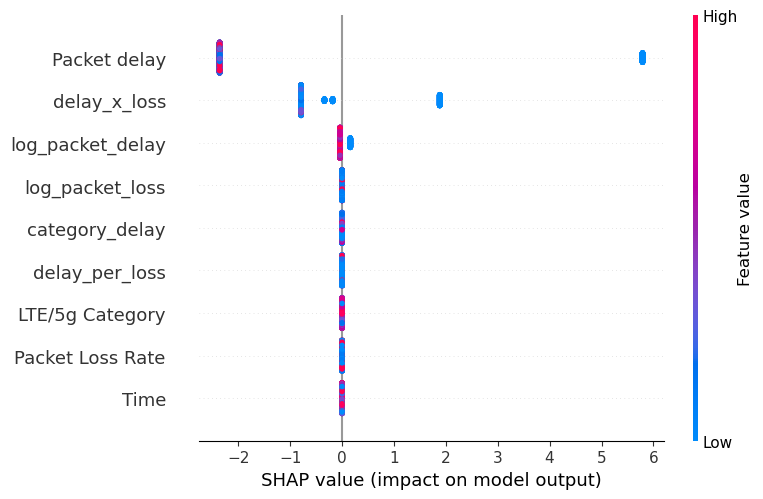


Saved: qos_probability_scores.csv


In [15]:
# STEP 7 — Final predictions + SHAP
import shap
import pandas as pd

# Feature names from the engineered feature set
feature_names = X_train.columns.tolist()

# FIXED: X_val_unscaled → X_cal (already a DataFrame, no need to wrap)
X_cal_df  = pd.DataFrame(X_cal.values,  columns=feature_names)
X_test_df = pd.DataFrame(X_test.values, columns=feature_names)

# Final probability scores on test set
final_proba = calibrated_model.predict_proba(X_test_df)

output_df = pd.DataFrame(final_proba,
    columns=["P_QoS_slice1", "P_QoS_slice2", "P_QoS_slice3"])
output_df["predicted_slice"] = le.inverse_transform(final_proba.argmax(axis=1))
output_df["risk_score"]      = 1 - final_proba.max(axis=1)

print(output_df.head(10))
print(f"\nRisk score stats:\n{output_df['risk_score'].describe().round(4)}")

# SHAP — explain model decisions on cal set
explainer = shap.TreeExplainer(best_model)
shap_vals = explainer.shap_values(X_cal_df)

# Handle both XGBoost (list) and LightGBM (3D array) output formats
shap_per_class = shap_vals if isinstance(shap_vals, list) \
                 else [shap_vals[:, :, i] for i in range(3)]

for class_idx in range(3):
    print(f"\nSHAP Summary — Slice Type {class_idx+1}")
    shap.summary_plot(shap_per_class[class_idx], X_cal_df,
                      feature_names=feature_names, show=True)

# Save output
output_df.to_csv("qos_probability_scores.csv", index=False)
print("\nSaved: qos_probability_scores.csv")

In [66]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, log_loss
from sklearn.preprocessing import LabelEncoder

train_df = pd.read_csv("train_dataset_prepared.csv")
le = LabelEncoder()
y = le.fit_transform(train_df["slice Type"])

clean_cols = ["Time", "Packet Loss Rate", "Packet delay", "LTE/5g Category"]
X_clean = train_df[clean_cols].copy()

m = xgb.XGBClassifier(objective="multi:softprob", num_class=3,
                        n_estimators=100, max_depth=4,
                        eval_metric="mlogloss", random_state=42,
                        verbosity=0, n_jobs=-1)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
aucs, lls = [], []
for tr_idx, val_idx in skf.split(X_clean, y):
    m.fit(X_clean.iloc[tr_idx], y[tr_idx])
    prob = m.predict_proba(X_clean.iloc[val_idx])
    aucs.append(roc_auc_score(y[val_idx], prob, multi_class='ovr', average='macro'))
    lls.append(log_loss(y[val_idx], prob))

print(f"AUC:     {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")
print(f"LogLoss: {np.mean(lls):.4f} ± {np.std(lls):.4f}")

print("\nSingle-feature AUC:")
for col in clean_cols:
    m2 = xgb.XGBClassifier(objective="multi:softprob", num_class=3,
                             n_estimators=50, eval_metric="mlogloss",
                             random_state=42, verbosity=0)
    m2.fit(X_clean[[col]], y)
    prob2 = m2.predict_proba(X_clean[[col]])
    print(f"  {col:25s}  AUC = {roc_auc_score(y, prob2, multi_class='ovr', average='macro'):.4f}")

print("\nMean feature values per slice type:")
print(train_df.groupby("slice Type")[clean_cols].mean().round(4).to_string())

AUC:     0.9920 ± 0.0010
LogLoss: 0.0941 ± 0.0077

Single-feature AUC:
  Time                       AUC = 0.5027
  Packet Loss Rate           AUC = 0.8005
  Packet delay               AUC = 0.9504
  LTE/5g Category            AUC = 0.5390

Mean feature values per slice type:
               Time  Packet Loss Rate  Packet delay  LTE/5g Category
slice Type                                                          
1           11.4994            0.0024      133.4807          10.4969
2           11.5196            0.0077      174.7605          11.5278
3           11.5238            0.0000       10.0000          11.4948


# step 8 - side by side comparison XGBoost vs lightGBM

Model                          AUC    LogLoss   Brier S1   Brier S2   Brier S3
------------------------------------------------------------------------------
XGBoost Baseline            0.9944     0.0776     0.0269     0.0269     0.0000
XGBoost Tuned               0.9954     0.0730     0.0259     0.0259     0.0000
LightGBM Baseline           0.9938     0.0843     0.0305     0.0306     0.0000
LightGBM Tuned              0.9951     0.0880     0.0316     0.0316     0.0000

Best AUC:      XGBoost Tuned
Best LogLoss:  XGBoost Tuned  ← use this for probability scoring


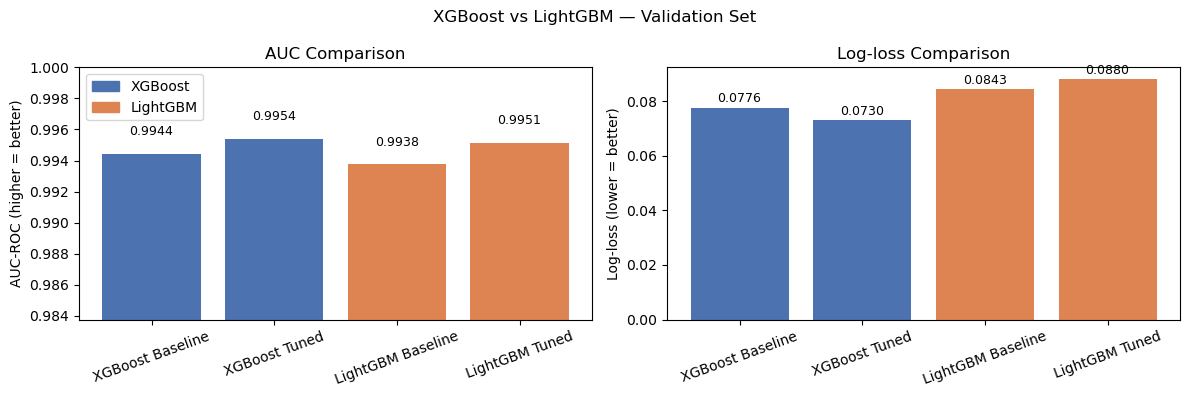


── XGBoost Tuned ──
              precision    recall  f1-score   support

     Slice 1       0.97      0.94      0.95       716
     Slice 2       0.87      0.92      0.89       313
     Slice 3       1.00      1.00      1.00       315

    accuracy                           0.95      1344
   macro avg       0.94      0.95      0.95      1344
weighted avg       0.95      0.95      0.95      1344


── LightGBM Tuned ──
              precision    recall  f1-score   support

     Slice 1       0.95      0.94      0.95       716
     Slice 2       0.87      0.90      0.88       313
     Slice 3       1.00      1.00      1.00       315

    accuracy                           0.94      1344
   macro avg       0.94      0.95      0.94      1344
weighted avg       0.95      0.94      0.95      1344



In [72]:
# STEP 8a — Head-to-head evaluation: XGBoost vs LightGBM
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss, classification_report
import pandas as pd
import numpy as np

models = {
    "XGBoost Baseline":  xgb_base,
    "XGBoost Tuned":     xgb_tuned,
    "LightGBM Baseline": lgb_base,
    "LightGBM Tuned":    lgb_tuned,
}

results = []
print(f"{'Model':<25} {'AUC':>8} {'LogLoss':>10} {'Brier S1':>10} {'Brier S2':>10} {'Brier S3':>10}")
print("-" * 78)

for name, model in models.items():
    proba = model.predict_proba(X_cal)
    auc   = roc_auc_score(y_cal, proba, multi_class='ovr', average='macro')
    ll    = log_loss(y_cal, proba)
    bs    = [brier_score_loss((y_cal == i).astype(int), proba[:, i]) for i in range(3)]
    results.append({"Model": name, "AUC": auc, "LogLoss": ll,
                    "Brier_S1": bs[0], "Brier_S2": bs[1], "Brier_S3": bs[2]})
    print(f"{name:<25} {auc:>8.4f} {ll:>10.4f} {bs[0]:>10.4f} {bs[1]:>10.4f} {bs[2]:>10.4f}")

results_df = pd.DataFrame(results)

# ── Winner summary ───────────────────────────────────────────────────────────
best_auc = results_df.loc[results_df["AUC"].idxmax(), "Model"]
best_ll  = results_df.loc[results_df["LogLoss"].idxmin(), "Model"]
print(f"\nBest AUC:      {best_auc}")
print(f"Best LogLoss:  {best_ll}  ← use this for probability scoring")

# ── Visual comparison ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ["#4C72B0", "#4C72B0", "#DD8452", "#DD8452"]  # blue=XGB, orange=LGB
bars_auc = axes[0].bar(results_df["Model"], results_df["AUC"], color=colors)
axes[0].set_ylim(results_df["AUC"].min() - 0.01, 1.0)
axes[0].set_ylabel("AUC-ROC (higher = better)")
axes[0].set_title("AUC Comparison")
axes[0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars_auc, results_df["AUC"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f"{val:.4f}", ha='center', va='bottom', fontsize=9)

bars_ll = axes[1].bar(results_df["Model"], results_df["LogLoss"], color=colors)
axes[1].set_ylabel("Log-loss (lower = better)")
axes[1].set_title("Log-loss Comparison")
axes[1].tick_params(axis='x', rotation=20)
for bar, val in zip(bars_ll, results_df["LogLoss"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f"{val:.4f}", ha='center', va='bottom', fontsize=9)

# Legend
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color="#4C72B0", label="XGBoost"),
                          Patch(color="#DD8452", label="LightGBM")])
plt.suptitle("XGBoost vs LightGBM — Validation Set")
plt.tight_layout()
plt.show()

# ── Per-class classification report for each tuned model ────────────────────
class_names = [f"Slice {le.inverse_transform([i])[0]}" for i in range(3)]
for name, model in [("XGBoost Tuned", xgb_tuned), ("LightGBM Tuned", lgb_tuned)]:
    print(f"\n── {name} ──")
    y_pred = model.predict_proba(X_cal).argmax(axis=1)
    print(classification_report(y_cal, y_pred, target_names=class_names))

# step 9 - Evaluation

  FINAL EVALUATION — unseen holdout set

AUC-ROC (macro OvR): 0.9943
Log-loss:            0.0790

Brier Score per class:
  Slice 1: 0.0279
  Slice 2: 0.0279
  Slice 3: 0.0000

Classification Report:
              precision    recall  f1-score   support

     Slice 1       0.92      0.97      0.94       716
     Slice 2       0.92      0.81      0.86       313
     Slice 3       1.00      1.00      1.00       315

    accuracy                           0.94      1344
   macro avg       0.95      0.93      0.94      1344
weighted avg       0.94      0.94      0.94      1344



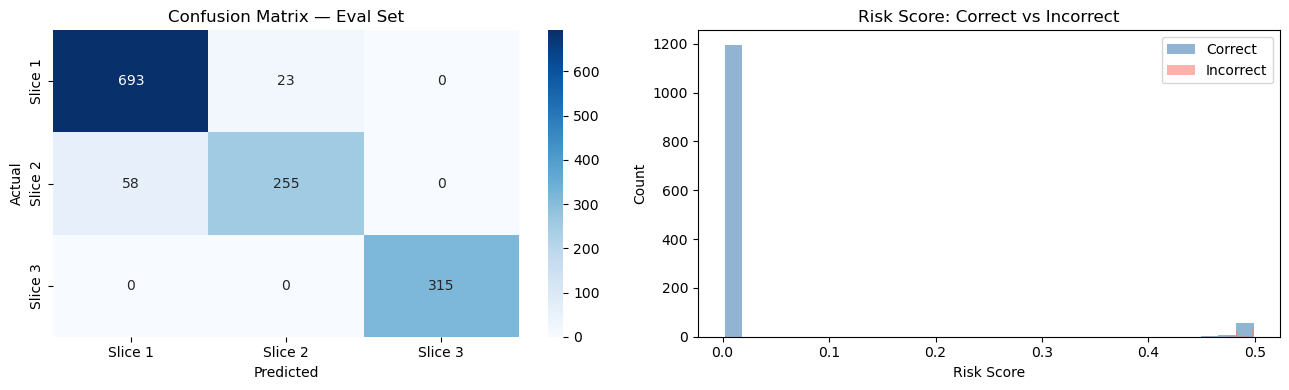


Risk score summary:
  Mean:                    0.0560
  High-risk (> 0.20):      149 (11.1%)
  Low-risk  (< 0.05):      1195 (88.9%)

Among high-risk predictions:
  Accuracy: 45.6%  ← model correctly flags its own uncertainty


In [73]:
       
# STEP 9 — Final honest evaluation on unseen eval set
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, log_loss, brier_score_loss)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Evaluate calibrated model on the untouched eval set
y_prob_eval = calibrated_model.predict_proba(X_eval)
y_pred_eval = y_prob_eval.argmax(axis=1)
class_names  = [f"Slice {le.inverse_transform([i])[0]}" for i in range(3)]

print("=" * 55)
print("  FINAL EVALUATION — unseen holdout set")
print("=" * 55)

# ── Global metrics ───────────────────────────────────────
auc = roc_auc_score(y_eval, y_prob_eval, multi_class='ovr', average='macro')
ll  = log_loss(y_eval, y_prob_eval)
print(f"\nAUC-ROC (macro OvR): {auc:.4f}")
print(f"Log-loss:            {ll:.4f}")

# ── Per-class Brier scores ───────────────────────────────
print("\nBrier Score per class:")
for i, name in enumerate(class_names):
    bs = brier_score_loss((y_eval == i).astype(int), y_prob_eval[:, i])
    print(f"  {name}: {bs:.4f}")

# ── Classification report ────────────────────────────────
print("\nClassification Report:")
print(classification_report(y_eval, y_pred_eval, target_names=class_names))

# ── Confusion matrix ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cm = confusion_matrix(y_eval, y_pred_eval)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names, ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("Confusion Matrix — Eval Set")

# ── Risk score distribution ──────────────────────────────
risk_scores = 1 - y_prob_eval.max(axis=1)
correct     = y_eval == y_pred_eval

axes[1].hist(risk_scores[correct],   bins=30, alpha=0.6,
             label="Correct",  color="steelblue")
axes[1].hist(risk_scores[~correct],  bins=30, alpha=0.6,
             label="Incorrect", color="salmon")
axes[1].set_xlabel("Risk Score")
axes[1].set_ylabel("Count")
axes[1].set_title("Risk Score: Correct vs Incorrect")
axes[1].legend()

plt.tight_layout()
plt.show()

# ── Risk score summary ───────────────────────────────────
print(f"\nRisk score summary:")
print(f"  Mean:                    {risk_scores.mean():.4f}")
print(f"  High-risk (> 0.20):      {(risk_scores > 0.20).sum()} "
      f"({(risk_scores > 0.20).mean():.1%})")
print(f"  Low-risk  (< 0.05):      {(risk_scores < 0.05).sum()} "
      f"({(risk_scores < 0.05).mean():.1%})")
print(f"\nAmong high-risk predictions:")
high_risk_mask = risk_scores > 0.20
if high_risk_mask.sum() > 0:
    hr_accuracy = (correct[high_risk_mask]).mean()
    print(f"  Accuracy: {hr_accuracy:.1%}  "
          f"← model correctly flags its own uncertainty")

# Saving models

In [1]:
import joblib

joblib.dump(calibrated_model, "best_lgb_calibrated.pkl")   # your LightGBM winner
joblib.dump(xgb_tuned,        "xgb_tuned.pkl")
joblib.dump(le,               "label_encoder.pkl")

# Save the eval set so both notebooks use the EXACT same rows
import numpy as np
np.save("X_eval.npy", X_eval.values)
np.save("y_eval.npy", y_eval)
np.save("feature_names.npy", np.array(X_eval.columns.tolist()))

print("Saved: LightGBM, XGBoost, label encoder, eval set")

NameError: name 'calibrated_model' is not defined